In [1]:
import numpy as np
import datetime
import matplotlib.pyplot as plt
import pickle
import pyproj
from pyproj import Proj, transform
import rasterio
from rasterio.plot import show
import matplotlib.colors as colors
import matplotlib.dates as mdates
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

In [2]:
roots = "C:/Users/simcosta/Documents/doc/Campo_2023/Campo_2023/Processados/"
file_names = ['dados_gps.pkl', 'dados_ctd.pkl', 'CTD1_REV.pkl', 'CTD2_REV.pkl', 'CTD3_REV.pkl', 'CTD4_REV.pkl', 'CTD5_REV.pkl',
             'ADCP1_UVSSC_REV.pkl', 'ADCP1_depth_REV.pkl', 'ADCP1_time_REV.pkl',
             'ADCP2_UVSSC_REV.pkl', 'ADCP2_depth_REV.pkl', 'ADCP2_time_REV.pkl',
            'ADCP3_UVSSC_REV.pkl', 'ADCP3_depth_REV.pkl', 'ADCP3_time_REV.pkl',
             'ADCP4_UVSSC_REV.pkl', 'ADCP4_depth_REV.pkl', 'ADCP4_time_REV.pkl']

# Dicionário para armazenar os dados já processados de velocidadee outros
data = {}

# Loop através dos nomes dos arquivos e carrega os dados usando pickle
for file_name in file_names:
    with open(roots+file_name, 'rb') as file:
        data[file_name.replace('.pkl', '')] = pickle.load(file)
        
        


In [3]:
ctd1 = np.array(data['CTD1_REV'])
ctd2 = np.array(data['CTD2_REV'])
ctd3 = np.array(data['CTD3_REV'])
ctd4 = np.array(data['CTD4_REV'])
ctd5 = np.array(data['CTD5_REV'])
z_norm = np.arange(0.3,8.55,0.05)




In [4]:
#220 m até o molhe

Text(1120, -3.5, '#L')

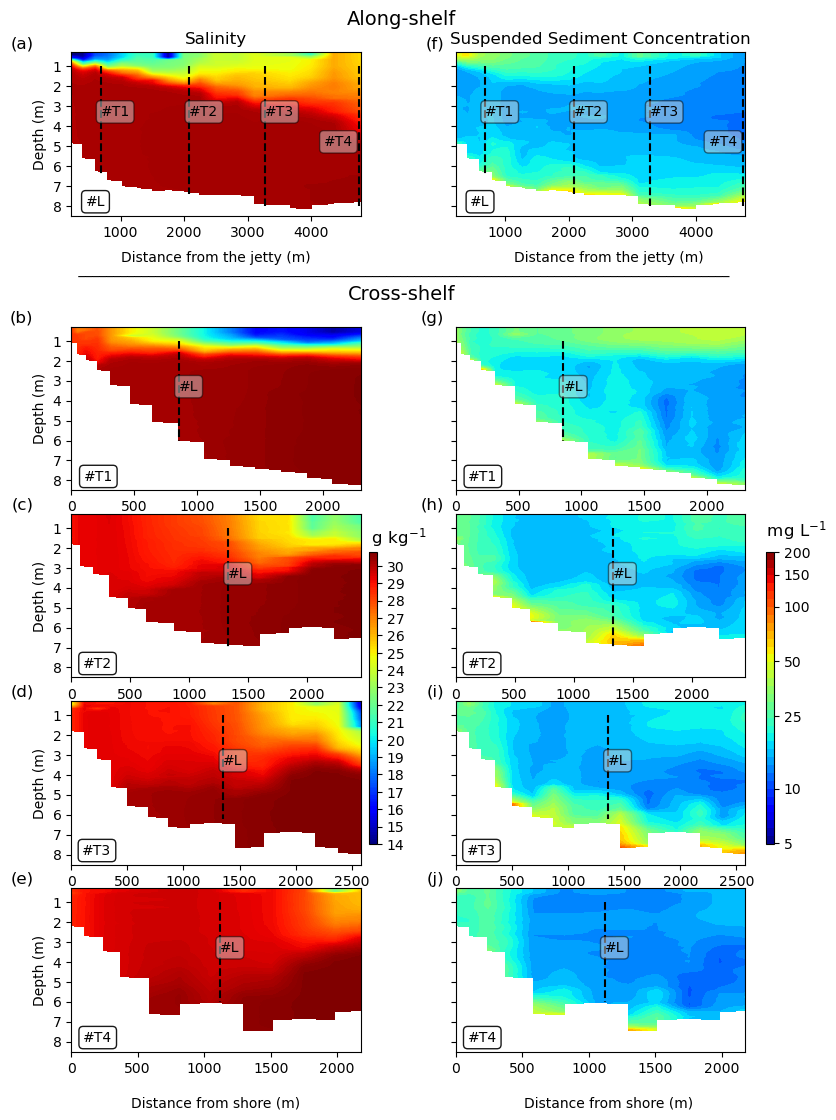

In [5]:
boxatrib = dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.9)
boxatrib2 = dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgrey", alpha=0.5)

# Array com as alturas proporcionais
depth = [8, 8, 8, 8, 8]
total_depth = sum(depth)

# Calcula as alturas proporcionais
proportions = [d / total_depth for d in depth]

# Posição inicial (x, y) para os primeiros eixos
x0_col1, y0_col1 = 0.1, 0.1
x0_col2, y0_col2 = 0.55, 0.1
width = 0.35  # Ajustado para deixar espaço para a colorbar no meio
spacing = 0.02  # Espaçamento fixo entre os eixos
spacing_between_cols = 0.015  # Espaçamento entre as duas colunas

# Calcula as alturas individuais (ajuste para deixar espaço para espaçamentos)
height1 = proportions[4] * 0.7
height2 = proportions[3] * 0.7
height3 = proportions[2] * 0.7
height4 = proportions[1] * 0.7
height5 = proportions[0] * 0.7

# Letras para cada subplot
letters_col1 = ['(e)', '(d)', '(c)', '(b)', '(a)']
letters_col2 = ['(j)', '(i)', '(h)', '(g)', '(f)']

# Calcula as posições y individuais para a coluna 1
y1_col1 = y0_col1
y2_col1 = y1_col1 + height1 + spacing
y3_col1 = y2_col1 + height2 + spacing
y4_col1 = y3_col1 + height3 + spacing
y5_col1 = y4_col1 + height4 + spacing + 0.075

# Calcula as posições y individuais para a coluna 2 (mesmas alturas, começando do mesmo y inicial)
y1_col2 = y0_col2
y2_col2 = y1_col2 + height1 + spacing
y3_col2 = y2_col2 + height2 + spacing
y4_col2 = y3_col2 + height3 + spacing
y5_col2 = y4_col2 + height4 + spacing + 0.075

# Define o tamanho da figura para preencher uma página A4
fig = plt.figure(figsize=(8.27, 11.69))

# Adiciona os eixos individualmente para a coluna 1
ax4_col1 = fig.add_axes([x0_col1, y1_col1, width, height1])
ax3_col1 = fig.add_axes([x0_col1, y2_col1, width, height2])
ax2_col1 = fig.add_axes([x0_col1, y3_col1, width, height3])
ax1_col1 = fig.add_axes([x0_col1, y4_col1, width, height4])
axw_col1 = fig.add_axes([x0_col1, y5_col1, width, height5])

# Adiciona os eixos individualmente para a coluna 2
ax4_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y1_col2, width, height1])
ax3_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y2_col2, width, height2])
ax2_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y3_col2, width, height3])
ax1_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y4_col2, width, height4])
axw_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y5_col2, width, height5])

# Adiciona letras nos cantos superiores esquerdos para a coluna 1
for ax, letter in zip([ax4_col1, ax3_col1, ax2_col1, ax1_col1, axw_col1], letters_col1):
    ax.text(-0.13, 1.1, letter, transform=ax.transAxes, fontsize=12, va='top', ha='right')

# Adiciona letras nos cantos superiores esquerdos para a coluna 2
for ax, letter in zip([ax4_col2, ax3_col2, ax2_col2, ax1_col2, axw_col2], letters_col2):
    ax.text(-0.04, 1.1, letter, transform=ax.transAxes, fontsize=12, va='top', ha='right')

# Adiciona o eixo da colorbar no meio da figura
mid_y_col = y0_col1 + (y5_col1 + height5 - y0_col1) / 2 - 0.25
cax = fig.add_axes([0.46, mid_y_col, 0.01, 0.25])

# Adiciona o eixo da colorbar à direita da figura
cax2 = fig.add_axes([0.94, mid_y_col, 0.01, 0.25])

axw_col1.set_title('Salinity')
axw_col1.annotate('#L', xy = (450, -8), bbox = boxatrib)
q = axw_col1.contourf((np.max(ctd1[7,0,:]) - ctd1[7,0,:]) +220, -z_norm, ctd1[0,:,:], np.arange(14, 30.9, 0.1),cmap=plt.cm.jet)
axw_col1.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [0, 1, 2, 3, 4, 5, 6, 7, 8])
axw_col1.set_ylabel('Depth (m)')

ax1_col1.annotate('#T1', xy = (100, -8), bbox = boxatrib)
q = ax1_col1.contourf(ctd2[7,0,:], -z_norm, ctd2[0,:,:],  np.arange(14, 30.9, 0.1),cmap=plt.cm.jet)
ax1_col1.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [0, 1, 2, 3, 4, 5, 6, 7, 8])
ax1_col1.set_ylabel('Depth (m)')

ax2_col1.annotate('#T2', xy = (100, -8), bbox = boxatrib)
q = ax2_col1.contourf(np.max(ctd3[7,0,:]) - ctd3[7,0,:], -z_norm, ctd3[0,:,:],  np.arange(14, 30.9, 0.1),cmap=plt.cm.jet)
ax2_col1.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [0, 1, 2, 3, 4, 5, 6, 7, 8])
ax2_col1.set_ylabel('Depth (m)')

ax3_col1.annotate('#T3', xy = (100, -8), bbox = boxatrib)
q = ax3_col1.contourf(ctd4[7,0,:], -z_norm, ctd4[0,:,:],  np.arange(14, 30.9, 0.1),cmap=plt.cm.jet)
ax3_col1.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [0, 1, 2, 3, 4, 5, 6, 7, 8])
ax3_col1.set_ylabel('Depth (m)')

ax4_col1.annotate('#T4', xy = (90, -8), bbox = boxatrib)
q = ax4_col1.contourf(np.max(ctd5[7,0,:]) - ctd5[7,0,:], -z_norm, ctd5[0,:,:],  np.arange(14, 30.9, 0.1),cmap=plt.cm.jet)
ax4_col1.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [0, 1, 2, 3, 4, 5, 6, 7, 8])
ax4_col1.set_ylabel('Depth (m)')

cbar = fig.colorbar(q, cax=cax, ticks = [14, 15, 16,17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
cbar.ax.set_title('          g kg$^{-1}$')

axw_col2.set_title('Suspended Sediment Concentration')
axw_col2.annotate('#L', xy = (450, -8), bbox = boxatrib)
q = axw_col2.contourf((np.max(ctd1[7,0,:]) - ctd1[7,0,:]) +220, -z_norm, np.log(ctd1[2,:,:]), np.arange(1.6, 5.4, 0.1), cmap=plt.cm.jet)
axw_col2.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])

ax1_col2.annotate('#T1', xy = (100, -8), bbox = boxatrib)
q = ax1_col2.contourf(ctd2[7,0,:], -z_norm, np.log(ctd2[2,:,:]), np.arange(1.6, 5.4, 0.1), cmap=plt.cm.jet)
ax1_col2.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])

ax2_col2.annotate('#T2', xy = (100, -8), bbox = boxatrib)
q = ax2_col2.contourf(np.max(ctd3[7,0,:]) - ctd3[7,0,:], -z_norm, np.log(ctd3[2,:,:]), np.arange(1.6, 5.4, 0.1), cmap=plt.cm.jet)
ax2_col2.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])

ax3_col2.annotate('#T3', xy = (100, -8), bbox = boxatrib)
q = ax3_col2.contourf(ctd4[7,0,:], -z_norm, np.log(ctd4[2,:,:]), np.arange(1.6, 5.4, 0.1), cmap=plt.cm.jet)
ax3_col2.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])


ax4_col2.annotate('#T4', xy = (90, -8), bbox = boxatrib)
q = ax4_col2.contourf(np.max(ctd5[7,0,:]) - ctd5[7,0,:], -z_norm, np.log(ctd5[2,:,:]), np.arange(1.6, 5.4, 0.1), cmap=plt.cm.jet)
ax4_col2.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])


cbar = fig.colorbar(q, cax=cax2, ticks = [1.6095, 2.303, 3.219, 3.9125, 4.6055, 5.011, 5.3])
yticks = np.exp([1.6095, 2.303, 3.219, 3.9125, 4.6055, 5.011, 5.3])
yticklabels = np.char.mod('%d', yticks.astype(int))
cbar.ax.set_yticklabels(yticklabels)
cbar.ax.set_title('          mg L$^{-1}$', pad = 11)


fig.text(0.5, y5_col1 + height5 + 0.02, 'Along-shelf', fontsize=14, ha='center', va='bottom')


fig.text(0.275, 0.773, 'Distance from the jetty (m)', ha='center', va='bottom')
fig.text(0.75, 0.773, 'Distance from the jetty (m)', ha='center', va='bottom')
fig.text(0.5, y4_col1 + height4 + 0.0425, ' _____________________________________________________________________________________________', fontsize=10, ha='center', va='bottom')
fig.text(0.5, y4_col1 + height4 + 0.02, 'Cross-shelf', fontsize=14, ha='center', va='bottom')

fig.text(0.275, 0.05, 'Distance from shore (m)', ha='center', va='bottom')
fig.text(0.75, 0.05, 'Distance from shore (m)', ha='center', va='bottom')


#alongshore transexto
axw_col1.annotate('#T1', xy = (683, -3.5), bbox = boxatrib2)
axw_col1.plot([683, 683],[-1, -6.4], color = 'k', ls = '--', lw = 1.5)
axw_col1.annotate('#T2', xy = (2081, -3.5), bbox = boxatrib2)
axw_col1.plot([2081, 2081],[-1, -7.4], color = 'k', ls = '--', lw = 1.5)
axw_col1.annotate('#T3', xy = (3274, -3.5), bbox = boxatrib2)
axw_col1.plot([3274, 3274],[-1, -8], color = 'k', ls = '--', lw = 1.5)
axw_col1.annotate('#T4', xy = (4200, -5), bbox = boxatrib2)
axw_col1.plot([4750, 4750],[-1, -8], color = 'k', ls = '--', lw = 1.5)
#
axw_col2.annotate('#T1', xy = (683, -3.5), bbox = boxatrib2)
axw_col2.plot([683, 683],[-1, -6.4], color = 'k', ls = '--', lw = 1.5)
axw_col2.annotate('#T2', xy = (2081, -3.5), bbox = boxatrib2)
axw_col2.plot([2081, 2081],[-1, -7.4], color = 'k', ls = '--', lw = 1.5)
axw_col2.annotate('#T3', xy = (3274, -3.5), bbox = boxatrib2)
axw_col2.plot([3274, 3274],[-1, -8], color = 'k', ls = '--', lw = 1.5)
axw_col2.annotate('#T4', xy = (4200, -5), bbox = boxatrib2)
axw_col2.plot([4750, 4750],[-1, -8], color = 'k', ls = '--', lw = 1.5)

#Cross-shore localização do longitudinal
ax1_col1.plot([857, 857],[-1, -6], color = 'k', ls = '--', lw = 1.5)
ax1_col1.annotate('#L', xy = (857, -3.5), bbox = boxatrib2)
ax2_col1.plot([1331, 1331],[-1, -7], color = 'k', ls = '--', lw = 1.5)
ax2_col1.annotate('#L', xy = (1331, -3.5), bbox = boxatrib2)
ax3_col1.plot([1355, 1355],[-1, -6.2], color = 'k', ls = '--', lw = 1.5)
ax3_col1.annotate('#L', xy = (1355, -3.5), bbox = boxatrib2)
ax4_col1.plot([1120, 1120],[-1, -6], color = 'k', ls = '--', lw = 1.5)
ax4_col1.annotate('#L', xy = (1120, -3.5), bbox = boxatrib2)
#
ax1_col2.plot([857, 857],[-1, -6], color = 'k', ls = '--', lw = 1.5)
ax1_col2.annotate('#L', xy = (857, -3.5), bbox = boxatrib2)
ax2_col2.plot([1331, 1331],[-1, -7], color = 'k', ls = '--', lw = 1.5)
ax2_col2.annotate('#L', xy = (1331, -3.5), bbox = boxatrib2)
ax3_col2.plot([1355, 1355],[-1, -6.2], color = 'k', ls = '--', lw = 1.5)
ax3_col2.annotate('#L', xy = (1355, -3.5), bbox = boxatrib2)
ax4_col2.plot([1120, 1120],[-1, -6], color = 'k', ls = '--', lw = 1.5)
ax4_col2.annotate('#L', xy = (1120, -3.5), bbox = boxatrib2)


In [6]:
fn = 'C:/Users/simcosta/Documents/doc/Campo_2023/Campo_2023/dados_brutos/SIMCOSTA_RS-5_MET_2023-11-28_2023-11-29.csv'

dataw = np.genfromtxt(fn, delimiter=',',skip_header=1)

# Convertendo a data e hora para datetime.datetime
dt = []
dt_stamp = []
for row in dataw[:]:
    dt.append(datetime.datetime(int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4]), int(row[5])))
    dt_stamp.append(datetime.datetime.timestamp(datetime.datetime(int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4]), int(row[5]))))

wind_pa = dataw[6:56, 6]
wind_mag = dataw[6:56, 7]
wind_dir = dataw[6:56, 8]


wU_spin = np.zeros(len(wind_mag))
wV_spin = np.zeros(len(wind_mag))



for j in range(len(wind_mag)):
    if (wind_mag[j] != 0):
        rot_ang = (wind_dir[j]+180-62)%360
        wU_spin[j] = wind_mag[j]*np.cos(np.radians(rot_ang))
        wV_spin[j] = wind_mag[j]*np.sin(np.radians(rot_ang))

roots = "C:/Users/simcosta/Documents/doc/Campo_2023/Campo_2023/Processados/"
with open(roots+'RS5_art3_time_rot.pkl', 'wb') as file:
    pickle.dump(dt, file)
with open(roots+'RS5_art3_U_rot.pkl', 'wb') as file:
    pickle.dump(wU_spin, file)
with open(roots+'RS5_art3_v_rot.pkl', 'wb') as file:
    pickle.dump(wV_spin, file)

(np.float64(-1.2100000000000002),
 np.float64(1.2100000000000002),
 np.float64(-1.2100000000000002),
 np.float64(1.2100000000000002))

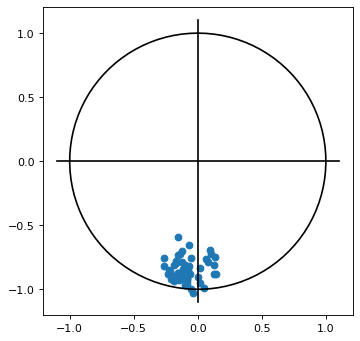

In [7]:
fig, ax = plt.subplots(figsize=(5,5), dpi = 80)


n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_y = np.cos(n)

ax.plot(circ_x, circ_y,'k')
ax.plot([0,0], [-1.1, 1.1], 'k')
ax.plot([-1.1, 1.1], [0, 0], 'k')

ax.scatter(wV_spin/10, wU_spin/10)
ax.axis('equal')

Text(2023-11-28 08:20:00, 1.15, '→')

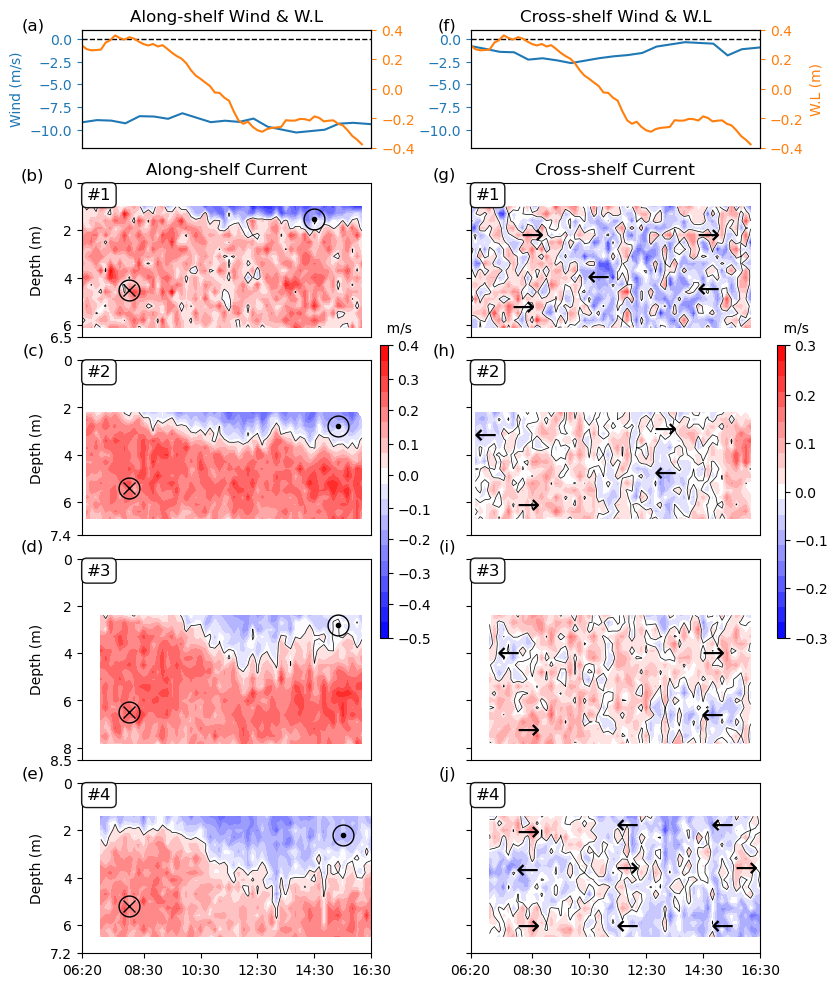

In [8]:
boxatrib = dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.9)



# Array com as alturas proporcionais
depth = [5, 6.5, 7.4, 8.5, 7.2]
total_depth = sum(depth)

# Calcula as alturas proporcionais
proportions = [d / total_depth for d in depth]

# Posição inicial (x, y) para os primeiros eixos
x0_col1, y0_col1 = 0.1, 0.1
x0_col2, y0_col2 = 0.55, 0.1
width = 0.35  # Ajustado para deixar espaço para a colorbar no meio
spacing = 0.02  # Espaçamento fixo entre os eixos
spacing_between_cols = 0.02  # Espaçamento entre as duas colunas

# Calcula as alturas individuais (ajuste para deixar espaço para espaçamentos)
height1 = proportions[4] * 0.7
height2 = proportions[3] * 0.7
height3 = proportions[2] * 0.7
height4 = proportions[1] * 0.7
height5 = proportions[0] * 0.7

# Letras para cada subplot
letters_col1 = ['(e)', '(d)', '(c)', '(b)', '(a)']
letters_col2 = ['(j)', '(i)', '(h)', '(g)', '(f)']

# Calcula as posições y individuais para a coluna 1
y1_col1 = y0_col1
y2_col1 = y1_col1 + height1 + spacing
y3_col1 = y2_col1 + height2 + spacing
y4_col1 = y3_col1 + height3 + spacing
y5_col1 = y4_col1 + height4 + spacing + 0.01

# Calcula as posições y individuais para a coluna 2 (mesmas alturas, começando do mesmo y inicial)
y1_col2 = y0_col2
y2_col2 = y1_col2 + height1 + spacing
y3_col2 = y2_col2 + height2 + spacing
y4_col2 = y3_col2 + height3 + spacing
y5_col2 = y4_col2 + height4 + spacing + 0.01

# Define o tamanho da figura para preencher uma página A4
fig = plt.figure(figsize=(8.27, 11.69))

# Adiciona os eixos individualmente para a coluna 1
ax4_col1 = fig.add_axes([x0_col1, y1_col1, width, height1])
ax3_col1 = fig.add_axes([x0_col1, y2_col1, width, height2])
ax2_col1 = fig.add_axes([x0_col1, y3_col1, width, height3])
ax1_col1 = fig.add_axes([x0_col1, y4_col1, width, height4])
axw_col1 = fig.add_axes([x0_col1, y5_col1, width, height5])

# Adiciona os eixos individualmente para a coluna 2
ax4_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y1_col2, width, height1])
ax3_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y2_col2, width, height2])
ax2_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y3_col2, width, height3])
ax1_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y4_col2, width, height4])
axw_col2 = fig.add_axes([x0_col2 + spacing_between_cols, y5_col2, width, height5])

# Adiciona letras nos cantos superiores esquerdos para a coluna 1
for ax, letter in zip([ax4_col1, ax3_col1, ax2_col1, ax1_col1, axw_col1], letters_col1):
    ax.text(-0.13, 1.1, letter, transform=ax.transAxes, fontsize=12, va='top', ha='right')

# Adiciona letras nos cantos superiores esquerdos para a coluna 2
for ax, letter in zip([ax4_col2, ax3_col2, ax2_col2, ax1_col2, axw_col2], letters_col2):
    ax.text(-0.05, 1.1, letter, transform=ax.transAxes, fontsize=12, va='top', ha='right')

# Adiciona o eixo da colorbar no meio da figura
mid_y_col = y0_col1 + (y5_col1 + height5 - y0_col1) / 2 - 0.125
cax = fig.add_axes([0.46, mid_y_col, 0.01, 0.25])

# Adiciona o eixo da colorbar à direita da figura
cax2 = fig.add_axes([0.94, mid_y_col, 0.01, 0.25])

z1 = np.arange(0.4, 5.8, 0.3)
z2 = np.arange(0.7, 5.5, 0.3)
z3 = np.arange(0.7, 6.4, 0.3)
z4 = np.arange(0.7, 6.1, 0.3)


ax1_col1.set_title('Along-shelf Current', fontsize = 12)
ax1_col1.annotate("#1", xy = (data['ADCP1_time_REV'][1], 5.8), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.5,vcenter = 0, vmax = 0.4)
q = ax1_col1.contourf(data['ADCP1_time_REV'], z1, data['ADCP1_UVSSC_REV'][0].T, np.round(np.linspace(-0.5, 0.4, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax1_col1.contour(data['ADCP1_time_REV'], z1, data['ADCP1_UVSSC_REV'][0].T, 0 , colors ='k', linewidths = .5)
ax1_col1.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax1_col1.set_ylim([0, 6.5])
ax1_col1.set_yticks([0, 0.5, 2.5, 4.5, 6.5], [6.5, 6 , 4 , 2 , 0 ])
ax1_col1.set_xticks([])
ax1_col1.set_ylabel('Depth (m)')



ax2_col1.annotate("#2", xy = (data['ADCP1_time_REV'][1], 6.7), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.5,vcenter = 0, vmax = 0.4)
q = ax2_col1.contourf(data['ADCP2_time_REV'], z2, data['ADCP2_UVSSC_REV'][0].T, np.round(np.linspace(-0.5, 0.4, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax2_col1.contour(data['ADCP2_time_REV'], z2, data['ADCP2_UVSSC_REV'][0].T, 0 , colors ='k', linewidths = .5)
ax2_col1.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax2_col1.set_ylim([0, 7.4])
ax2_col1.set_yticks([0, 1.4, 3.4, 5.4, 7.4], [7.4, 6 , 4 , 2 , 0])
ax2_col1.set_xticks([])
ax2_col1.set_ylabel('Depth (m)')



ax3_col1.annotate("#3", xy = (data['ADCP1_time_REV'][1], 7.8), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.5,vcenter = 0, vmax = 0.4)
q = ax3_col1.contourf(data['ADCP3_time_REV'], z3, data['ADCP3_UVSSC_REV'][0].T, np.round(np.linspace(-0.5, 0.4, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax3_col1.contour(data['ADCP3_time_REV'], z3, data['ADCP3_UVSSC_REV'][0].T, 0 , colors ='k', linewidths = .5)
ax3_col1.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax3_col1.set_ylim([0, 8.5])
ax3_col1.set_yticks([0, 0.5, 2.5, 4.5, 6.5, 8.5], [8.5, 8, 6, 4, 2 , 0])
ax3_col1.set_xticks([])
ax3_col1.set_ylabel('Depth (m)')



ax4_col1.annotate("#4", xy = (data['ADCP1_time_REV'][1], 6.5), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.5,vcenter = 0, vmax = 0.4)
q = ax4_col1.contourf(data['ADCP4_time_REV'], z4, data['ADCP4_UVSSC_REV'][0].T, np.round(np.linspace(-0.5, 0.4, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax4_col1.contour(data['ADCP4_time_REV'], z4, data['ADCP4_UVSSC_REV'][0].T, 0 , colors ='k', linewidths = .5)
ax4_col1.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax4_col1.set_xticks([data['ADCP1_time_REV'][0],
                     data['ADCP1_time_REV'][13],
                     data['ADCP1_time_REV'][25],
                     data['ADCP1_time_REV'][37],
                     data['ADCP1_time_REV'][49],
                     data['ADCP4_time_REV'][-1]])

ax4_col1.set_ylim([0, 7.2])
ax4_col1.set_yticks([0, 1.2, 3.2, 5.2,  7.2], [7.2, 6, 4, 2, 0])

cbar = fig.colorbar(q, cax=cax, ticks = [-0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4])
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('       m/s', fontsize=10, pad=10)
myFmt = mdates.DateFormatter('%H:%M')
ax4_col1.xaxis.set_major_formatter(myFmt)
ax4_col1.set_ylabel('Depth (m)')

ax1_col2.set_title('Cross-shelf Current', fontsize = 12)
ax1_col2.annotate("#1", xy = (data['ADCP1_time_REV'][1], 5.8), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.3,vcenter = 0, vmax = 0.3)
q = ax1_col2.contourf(data['ADCP1_time_REV'], z1, data['ADCP1_UVSSC_REV'][1].T, np.round(np.linspace(-0.3, 0.3, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax1_col2.contour(data['ADCP1_time_REV'], z1, data['ADCP1_UVSSC_REV'][1].T, 0 , colors ='k', linewidths = .5)
ax1_col2.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax1_col2.set_ylim([0, 6.5])
ax1_col2.set_yticks([0, 0.5, 2.5, 4.5, 6.5], [])
ax1_col2.set_xticks([])


ax2_col2.annotate("#2", xy = (data['ADCP1_time_REV'][1], 6.7), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.3,vcenter = 0, vmax = 0.3)
q = ax2_col2.contourf(data['ADCP2_time_REV'], z2, data['ADCP2_UVSSC_REV'][1].T, np.round(np.linspace(-0.3, 0.3, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax2_col2.contour(data['ADCP2_time_REV'], z2, data['ADCP2_UVSSC_REV'][1].T, 0 , colors ='k', linewidths = .5)
ax2_col2.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax2_col2.set_ylim([0, 7.4])
ax2_col2.set_yticks([0, 1.4, 3.4, 5.4, 7.4], [])
ax2_col2.set_xticks([])



ax3_col2.annotate("#3", xy = (data['ADCP1_time_REV'][1], 7.8), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.3,vcenter = 0, vmax = 0.3)
q = ax3_col2.contourf(data['ADCP3_time_REV'], z3, data['ADCP3_UVSSC_REV'][1].T, np.round(np.linspace(-0.3, 0.3, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax3_col2.contour(data['ADCP3_time_REV'], z3, data['ADCP3_UVSSC_REV'][1].T, 0 , colors ='k', linewidths = .5)
ax3_col2.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax3_col2.set_ylim([0, 8.5])
ax3_col2.set_yticks([0, 0.5, 2.5, 4.5, 6.5, 8.5], [])
ax3_col2.set_xticks([])



ax4_col2.annotate("#4", xy = (data['ADCP1_time_REV'][1], 6.5), fontsize=12, bbox = boxatrib)
divnorm = colors.TwoSlopeNorm(vmin = -0.3,vcenter = 0, vmax = 0.3)
q = ax4_col2.contourf(data['ADCP4_time_REV'], z4, data['ADCP4_UVSSC_REV'][1].T, np.round(np.linspace(-0.3, 0.3, 20),2), cmap=plt.cm.bwr, norm = divnorm)
ax4_col2.contour(data['ADCP4_time_REV'], z4, data['ADCP4_UVSSC_REV'][1].T, 0 , colors ='k', linewidths = .5)
ax4_col2.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
ax4_col2.set_xticks([data['ADCP1_time_REV'][0],
                     data['ADCP1_time_REV'][13],
                     data['ADCP1_time_REV'][25],
                     data['ADCP1_time_REV'][37],
                     data['ADCP1_time_REV'][49],
                     data['ADCP4_time_REV'][-1]])

ax4_col2.set_ylim([0, 7.2])
ax4_col2.set_yticks([0, 1.2, 3.2, 5.2, 7.2], [])

cbar = fig.colorbar(q, cax=cax2, ticks = [0.3, 0.2, 0.1, 0, -0.1, -0.2, -0.3])
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_title('       m/s', fontsize=10, pad=10)
myFmt = mdates.DateFormatter('%H:%M')
ax4_col2.xaxis.set_major_formatter(myFmt)

axw_col1.set_title('Along-shelf Wind & W.L', fontsize = 12)
axw_col1.plot(dt[6:56], wU_spin, color ='tab:blue')
axw_col1.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
axw_col1.set_ylim([-12, 1])
axw_col1.set_yticks([-10, -7.5, -5, -2.5, 0])
axw_col1.tick_params(axis='y', colors='tab:blue')
axw_col1.axhline(y=0, ls = '--', color ='k', lw=1)
axw_col1.set_xticks([])
axw_col1.set_ylabel('Wind (m/s)', color = 'tab:blue')


#depth
axw_col11 = axw_col1.twinx()
axw_col11.plot(data['ADCP1_time_REV'], (data['ADCP1_depth_REV'] - np.nanmean(data['ADCP1_depth_REV'])), color = 'tab:orange')
axw_col11.tick_params(axis='y', colors='tab:orange')
axw_col11.set_ylim([-.4, .4])

axw_col2.set_title('Cross-shelf Wind & W.L', fontsize = 12)
axw_col2.plot(dt[6:56], wV_spin, color ='tab:blue')
axw_col2.set_xlim([data['ADCP1_time_REV'][0], data['ADCP4_time_REV'][-1]])
axw_col2.set_ylim([-12, 1])
axw_col2.set_yticks([-10, -7.5, -5, -2.5, 0])
axw_col2.tick_params(axis='y', colors='tab:blue')
axw_col2.axhline(y=0, ls = '--', color ='k', lw=1)
axw_col2.set_xticks([])

#depth
axw_col22 = axw_col2.twinx()
axw_col22.plot(data['ADCP1_time_REV'], (data['ADCP1_depth_REV'] - np.nanmean(data['ADCP1_depth_REV'])), color = 'tab:orange')
axw_col22.tick_params(axis='y', colors='tab:orange')
axw_col22.set_ylim([-.4, .4])
axw_col22.set_ylabel('W.L (m)', color = 'tab:orange')


#inflow
#
ax1_col1.plot(data['ADCP1_time_REV'][49], 5, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax1_col1.plot(data['ADCP1_time_REV'][49], 5, 'o', markersize=3, markerfacecolor='black', color ='k') 
#
ax2_col1.plot(data['ADCP1_time_REV'][54], 4.6, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax2_col1.plot(data['ADCP1_time_REV'][54], 4.6, 'o', markersize=3, markerfacecolor='black', color ='k') 
#
ax3_col1.plot(data['ADCP1_time_REV'][54], 5.7, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax3_col1.plot(data['ADCP1_time_REV'][54], 5.7, 'o', markersize=3, markerfacecolor='black', color ='k') 
#
ax4_col1.plot(data['ADCP1_time_REV'][55], 5, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax4_col1.plot(data['ADCP1_time_REV'][55], 5, 'o', markersize=3, markerfacecolor='black', color ='k') 

#outflow
#
ax1_col1.plot(data['ADCP1_time_REV'][10], 2, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax1_col1.plot(data['ADCP1_time_REV'][10], 2, 'x', markersize=9, markeredgewidth=1, color ='k') 
#
ax2_col1.plot(data['ADCP1_time_REV'][10], 2, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax2_col1.plot(data['ADCP1_time_REV'][10], 2, 'x', markersize=9, markeredgewidth=1, color ='k') 
#
ax3_col1.plot(data['ADCP1_time_REV'][10], 2, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax3_col1.plot(data['ADCP1_time_REV'][10], 2, 'x', markersize=9, markeredgewidth=1, color ='k') 
#
ax4_col1.plot(data['ADCP1_time_REV'][10], 2, 'o', markersize=15, markerfacecolor='none', markeredgewidth=1, color ='k')
ax4_col1.plot(data['ADCP1_time_REV'][10], 2, 'x', markersize=9, markeredgewidth=1, color ='k') 

#to coast
ax1_col2.text(data['ADCP1_time_REV'][50], 2, '←', fontsize=20, ha='center', va='center')
ax1_col2.text(data['ADCP1_time_REV'][27], 2.5, '←', fontsize=20, ha='center', va='center')
ax2_col2.text(data['ADCP1_time_REV'][3], 4.2, '←', fontsize=20, ha='center', va='center')
ax2_col2.text(data['ADCP1_time_REV'][41], 2.6, '←', fontsize=20, ha='center', va='center')
ax3_col2.text(data['ADCP1_time_REV'][51], 1.85, '←', fontsize=20, ha='center', va='center')
ax3_col2.text(data['ADCP1_time_REV'][8], 4.5, '←', fontsize=20, ha='center', va='center')

ax4_col2.text(data['ADCP1_time_REV'][12], 3.5, '←', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][53], 1.15, '←', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][33], 1.15, '←', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][33], 5.4, '←', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][53], 5.4, '←', fontsize=20, ha='center', va='center')

#to ocean
ax1_col2.text(data['ADCP1_time_REV'][11], 1.25, '→', fontsize=20, ha='center', va='center')
ax1_col2.text(data['ADCP1_time_REV'][50], 4.3, '→', fontsize=20, ha='center', va='center')
ax1_col2.text(data['ADCP1_time_REV'][13], 4.3, '→', fontsize=20, ha='center', va='center')
ax2_col2.text(data['ADCP1_time_REV'][12], 1.25, '→', fontsize=20, ha='center', va='center')
ax2_col2.text(data['ADCP1_time_REV'][41], 4.45, '→', fontsize=20, ha='center', va='center')
ax3_col2.text(data['ADCP1_time_REV'][12], 1.25, '→', fontsize=20, ha='center', va='center')
ax3_col2.text(data['ADCP1_time_REV'][51], 4.5, '→', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][33], 3.6, '→', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][58], 3.6, '→', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][12], 5.1, '→', fontsize=20, ha='center', va='center')
ax4_col2.text(data['ADCP1_time_REV'][12], 1.15, '→', fontsize=20, ha='center', va='center')

Text(0.5, 1.0, 'Density')

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


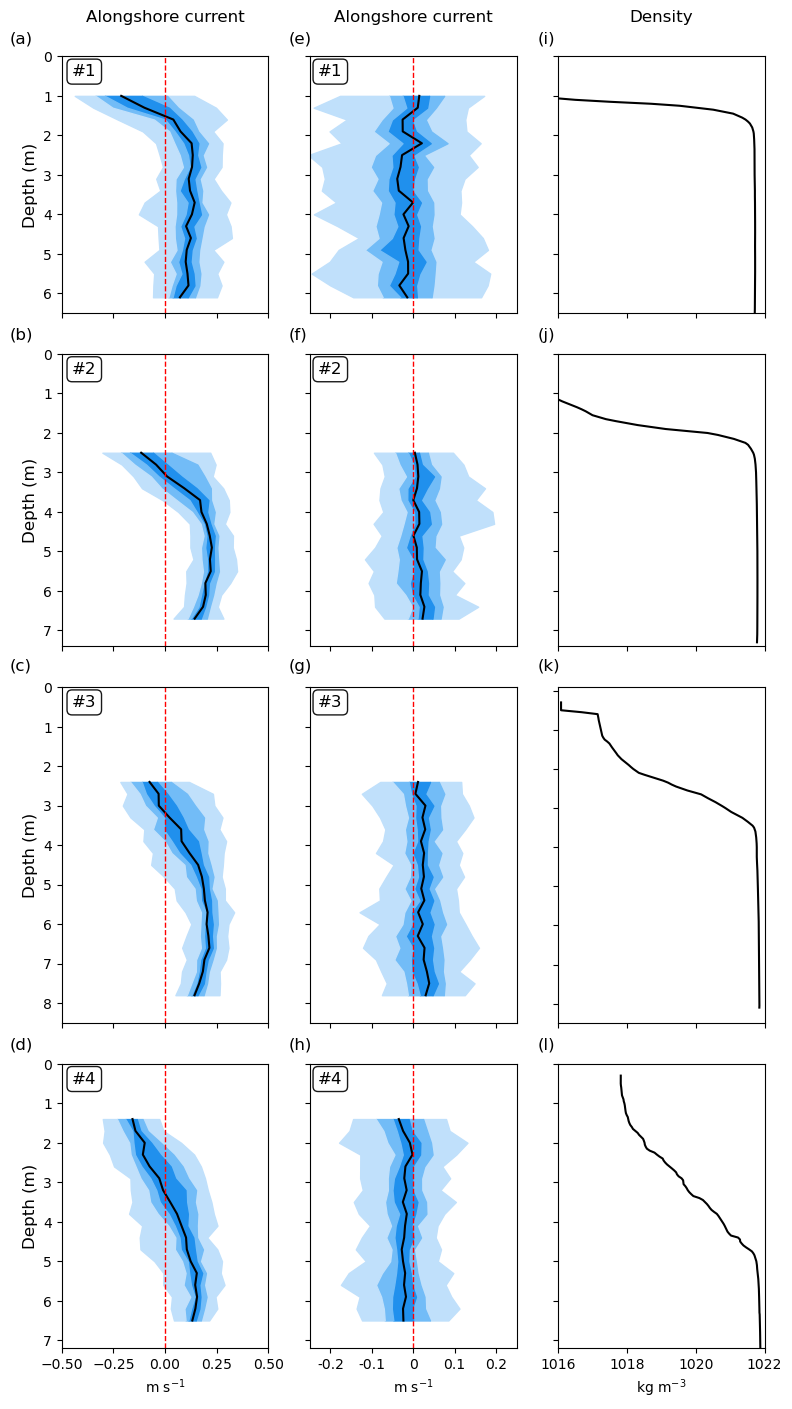

In [9]:
colors = ["#0B3861", "#1565C0", "#1976D2", "#1E88E5", "#2196F3", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB", "#E3F2FD"]
cmap = LinearSegmentedColormap.from_list("", colors)

# Array com as alturas proporcionais
depth = [6.5, 7.4, 8.5, 7.2]
total_depth = sum(depth)

# Calcula as alturas proporcionais
proportions = [d / total_depth for d in depth]

dx = 0.25  # Largura dos gráficos
spacing = 0.035  # Espaçamento ajustável entre as linhas

fig = plt.figure(figsize=(8.27, 11.69), dpi=100, constrained_layout=True)

# Função para calcular a posição vertical acumulada
def get_y_positions(proportions, spacing):
    positions = []
    current_y = 1.0  # Começar do topo da figura
    for p in proportions:
        positions.append(current_y - p)
        current_y -= (p + spacing)
    return positions

# Posições verticais para cada gráfico
y_positions = get_y_positions(proportions, spacing)

# Primeira coluna
ax1 = fig.add_axes([0.05, y_positions[0], dx, proportions[0]])
ax2 = fig.add_axes([0.05, y_positions[1], dx, proportions[1]])
ax3 = fig.add_axes([0.05, y_positions[2], dx, proportions[2]])
ax4 = fig.add_axes([0.05, y_positions[3], dx, proportions[3]])

# Segunda coluna
ax5 = fig.add_axes([0.35, y_positions[0], dx, proportions[0]])
ax6 = fig.add_axes([0.35, y_positions[1], dx, proportions[1]])
ax7 = fig.add_axes([0.35, y_positions[2], dx, proportions[2]])
ax8 = fig.add_axes([0.35, y_positions[3], dx, proportions[3]])

# Terceira coluna
ax9 = fig.add_axes([0.65, y_positions[0], dx, proportions[0]])
ax10 = fig.add_axes([0.65, y_positions[1], dx, proportions[1]])
ax11 = fig.add_axes([0.65, y_positions[2], dx, proportions[2]])
ax12 = fig.add_axes([0.65, y_positions[3], dx, proportions[3]])




#1 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP1_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax1.fill_betweenx(z1, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax1.fill_betweenx(z1, guarda65, guarda80, z1, color = cmap(0.7), label='80th percentile')
ax1.fill_betweenx(z1, guarda50, guarda65, z1, color = cmap(0.4), label='65th percentile')
ax1.plot(guarda50, z1, 'k', label='Median')
ax1.fill_betweenx(z1, guarda35, guarda50, z1, color = cmap(0.4), label='35th percentile')
ax1.fill_betweenx(z1, guarda20, guarda35, z1, color = cmap(0.7), label='20th percentile')
ax1.fill_betweenx(z1, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax1.fill_betweenx(guarda01, z1, color = 'w')

ax1.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax1.set_xlim([-0.5, 0.5])
ax1.text(-0.25, 1.05, '(a)', transform=ax1.transAxes, fontsize=12)
ax1.set_ylim([0, 6.5])
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], [6, 5 , 4 , 3 , 2 , 1, 0])
ax1.set_xticklabels([])
ax1.annotate("#1", xy = (-0.45, 6), fontsize=12, bbox = boxatrib)


#2 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(15):
    g = np.transpose(data['ADCP2_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))#
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax2.fill_betweenx(z2[:15], guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax2.fill_betweenx(z2[:15], guarda65, guarda80, z2[:15], color = cmap(0.7), label='80th percentile')
ax2.fill_betweenx(z2[:15], guarda50, guarda65, z2[:15], color = cmap(0.4), label='65th percentile')
ax2.plot(guarda50, z2[:15], 'k', label='Median')
ax2.fill_betweenx(z2[:15], guarda35, guarda50, z2[:15], color = cmap(0.4), label='35th percentile')
ax2.fill_betweenx(z2[:15], guarda20, guarda35, z2[:15], color = cmap(0.7), label='20th percentile')
ax2.fill_betweenx(z2[:15], guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax2.fill_betweenx(guarda01, z2[:15], color = 'w')

ax2.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax2.set_xlim([-0.5, 0.5])
ax2.text(-0.25, 1.05, '(b)', transform=ax2.transAxes, fontsize=12)
ax2.set_ylim([0, 7.4])
ax2.set_ylabel('Depth (m)', fontsize=12)
ax2.set_yticks([.4, 1.4, 2.4, 3.4, 4.4, 5.4, 6.4, 7.4], [7, 6, 5, 4, 3, 2, 1, 0])
ax2.set_xticklabels([])
ax2.annotate("#2", xy = (-0.45, 6.9), fontsize=12, bbox = boxatrib)


#3 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(19):
    g = np.transpose(data['ADCP3_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax3.fill_betweenx(z3, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax3.fill_betweenx(z3, guarda65, guarda80, z3, color = cmap(0.7), label='80th percentile')
ax3.fill_betweenx(z3, guarda50, guarda65, z3, color = cmap(0.4), label='65th percentile')
ax3.plot(guarda50, z3, 'k', label='Median')
ax3.fill_betweenx(z3, guarda35, guarda50, z3, color = cmap(0.4), label='35th percentile')
ax3.fill_betweenx(z3, guarda20, guarda35, z3, color = cmap(0.7), label='20th percentile')
ax3.fill_betweenx(z3, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax3.fill_betweenx(guarda01, z3, color = 'w')

ax3.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax3.set_xlim([-0.5, 0.5])
ax3.text(-0.25, 1.05, '(c)', transform=ax3.transAxes, fontsize=12)
ax3.set_ylim([0, 8.5])
ax3.set_ylabel('Depth (m)', fontsize=12)
ax3.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5], [8, 7, 6, 5, 4, 3, 2, 1, 0])
ax3.set_xticklabels([])
ax3.annotate("#3", xy = (-0.45, 8), fontsize=12, bbox = boxatrib)


#4- U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP4_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax4.fill_betweenx(z4, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax4.fill_betweenx(z4, guarda65, guarda80, z4, color = cmap(0.7), label='80th percentile')
ax4.fill_betweenx(z4, guarda50, guarda65, z4, color = cmap(0.4), label='65th percentile')
ax4.plot(guarda50, z4, 'k', label='Median')
ax4.fill_betweenx(z4, guarda35, guarda50, z4, color = cmap(0.4), label='35th percentile')
ax4.fill_betweenx(z4, guarda20, guarda35, z4, color = cmap(0.7), label='20th percentile')
ax4.fill_betweenx(z4, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax4.fill_betweenx(guarda01, z4, color = 'w')

ax4.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax4.set_xlim([-0.5, 0.5])
ax4.text(-0.25, 1.05, '(d)', transform=ax4.transAxes, fontsize=12)
ax4.set_ylim([0, 7.2])
ax4.set_ylabel('Depth (m)', fontsize=12)
ax4.set_yticks([.2, 1.2, 2.2, 3.2, 4.2, 5.2, 6.2, 7.2], [7, 6, 5, 4, 3, 2, 1, 0])
ax4.set_xlabel('m s$^{-1}$')
ax4.annotate("#4", xy = (-0.45, 6.7), fontsize=12, bbox = boxatrib)


#5 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP1_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax5.fill_betweenx(z1, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax5.fill_betweenx(z1, guarda65, guarda80, z1, color = cmap(0.7), label='80th percentile')
ax5.fill_betweenx(z1, guarda50, guarda65, z1, color = cmap(0.4), label='65th percentile')
ax5.plot(guarda50, z1, 'k', label='Median')
ax5.fill_betweenx(z1, guarda35, guarda50, z1, color = cmap(0.4), label='35th percentile')
ax5.fill_betweenx(z1, guarda20, guarda35, z1, color = cmap(0.7), label='20th percentile')
ax5.fill_betweenx(z1, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax5.fill_betweenx(guarda01, z1, color = 'w')

ax5.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax5.set_xlim([-0.25, 0.25])
ax5.text(-0.1, 1.05, '(e)', transform=ax5.transAxes, fontsize=12)
ax5.set_ylim([0, 6.5])
ax5.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], [])
ax5.set_xticks([-.2, -.1, 0, .1, .2], [])
ax5.annotate("#1", xy = (-0.23, 6), fontsize=12, bbox = boxatrib)


#6 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(15):
    g = np.transpose(data['ADCP2_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))#
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax6.fill_betweenx(z2[:15], guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax6.fill_betweenx(z2[:15], guarda65, guarda80, z2[:15], color = cmap(0.7), label='80th percentile')
ax6.fill_betweenx(z2[:15], guarda50, guarda65, z2[:15], color = cmap(0.4), label='65th percentile')
ax6.plot(guarda50, z2[:15], 'k', label='Median')
ax6.fill_betweenx(z2[:15], guarda35, guarda50, z2[:15], color = cmap(0.4), label='35th percentile')
ax6.fill_betweenx(z2[:15], guarda20, guarda35, z2[:15], color = cmap(0.7), label='20th percentile')
ax6.fill_betweenx(z2[:15], guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax6.fill_betweenx(guarda01, z2[:15], color = 'w')

ax6.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax6.set_xlim([-0.25, 0.25])
ax6.text(-0.1, 1.05, '(f)', transform=ax6.transAxes, fontsize=12)
ax6.set_ylim([0, 7.4])
ax6.set_yticks([.4, 1.4, 2.4, 3.4, 4.4, 5.4, 6.4, 7.4], [])
ax6.set_xticks([-.2, -.1, 0, .1, .2], [])
ax6.annotate("#2", xy = (-0.23, 6.9), fontsize=12, bbox = boxatrib)

#7 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(19):
    g = np.transpose(data['ADCP3_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax7.fill_betweenx(z3, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax7.fill_betweenx(z3, guarda65, guarda80, z3, color = cmap(0.7), label='80th percentile')
ax7.fill_betweenx(z3, guarda50, guarda65, z3, color = cmap(0.4), label='65th percentile')
ax7.plot(guarda50, z3, 'k', label='Median')
ax7.fill_betweenx(z3, guarda35, guarda50, z3, color = cmap(0.4), label='35th percentile')
ax7.fill_betweenx(z3, guarda20, guarda35, z3, color = cmap(0.7), label='20th percentile')
ax7.fill_betweenx(z3, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax7.fill_betweenx(guarda01, z3, color = 'w')

ax7.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax7.set_xlim([-0.25, 0.25])
ax7.text(-0.1, 1.05, '(g)', transform=ax7.transAxes, fontsize=12)
ax7.set_ylim([0, 8.5])
ax7.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5], [])
ax7.set_xticks([-.2, -.1, 0, .1, .2], [])
ax7.annotate("#3", xy = (-0.23, 8), fontsize=12, bbox = boxatrib)

#8- U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP4_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax8.fill_betweenx(z4, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax8.fill_betweenx(z4, guarda65, guarda80, z4, color = cmap(0.7), label='80th percentile')
ax8.fill_betweenx(z4, guarda50, guarda65, z4, color = cmap(0.4), label='65th percentile')
ax8.plot(guarda50, z4, 'k', label='Median')
ax8.fill_betweenx(z4, guarda35, guarda50, z4, color = cmap(0.4), label='35th percentile')
ax8.fill_betweenx(z4, guarda20, guarda35, z4, color = cmap(0.7), label='20th percentile')
ax8.fill_betweenx(z4, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax8.fill_betweenx(guarda01, z4, color = 'w')

ax8.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax8.set_xlim([-0.25, 0.25])
ax8.text(-0.1, 1.05, '(h)', transform=ax8.transAxes, fontsize=12)
ax8.set_ylim([0, 7.2])
ax8.set_yticks([.2, 1.2, 2.2, 3.2, 4.2, 5.2, 6.2, 7.2], [])
ax8.set_xlabel('m s$^{-1}$')
ax8.set_xticks([-.2, -.1, 0, .1, .2], [-.2, -.1, 0, .1, .2])
ax8.annotate("#4", xy = (-0.23, 6.7), fontsize=12, bbox = boxatrib)


ax9.plot(ctd1[6,:,13], -z_norm, color ='k')
ax9.set_xlim([1016, 1022])
ax9.set_ylim([-6.5, 0])
ax9.set_yticks([0, -1, -2, -3, -4, -5, -6], [])
ax9.text(-0.1, 1.05, '(i)', transform=ax9.transAxes, fontsize=12)
ax9.set_xticklabels([])
ax9.annotate("CTD-1 | 07h:28m", xy = (23.8, -.5), fontsize=12, bbox = boxatrib)


ax10.plot(ctd1[6,:,8], -z_norm, color ='k')
ax10.set_xlim([1016, 1022])
ax10.set_ylim([-7.4, 0])
ax10.set_yticks([0, -1, -2, -3, -4, -5, -6, -7], [])
ax10.text(-0.1, 1.05, '(j)', transform=ax10.transAxes, fontsize=12)
ax10.set_xticklabels([])
ax10.annotate("CTD-1 | 07h:20m", xy = (23.8, -.5), fontsize=12, bbox = boxatrib)


ax11.plot(ctd1[6,:,3], -z_norm, color ='k')
ax11.set_xlim([1016, 1022])
ax12.set_ylim([-8.5, 0])
ax11.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])
ax11.text(-0.1, 1.05, '(k)', transform=ax11.transAxes, fontsize=12)
ax11.set_xticklabels([])
ax11.annotate("CTD-1 | 07h:07m", xy = (23.8, -.5), fontsize=12, bbox = boxatrib)


ax12.plot(ctd1[6,:,0], -z_norm, color ='k')
ax12.set_xlim([1016, 1022])
ax12.set_ylim([-7.2, 0])
ax12.set_yticks([0, -1, -2, -3, -4, -5, -6, -7], [])
ax12.text(-0.1, 1.05, '(l)', transform=ax12.transAxes, fontsize=12)
ax12.set_xlabel('kg m$^{-3}$')
ax12.annotate("CTD-1 | 06h:59m", xy = (23.8, -.5), fontsize=12, bbox = boxatrib)

ax1.set_title('Alongshore current', pad = 25)
ax5.set_title('Alongshore current', pad = 25)
ax9.set_title('Density', pad = 25)

In [10]:

def shear_wc(velocity, density, nivel, sed_size):
    t_mc_array = []
    ucr = []
    lengths = len(nivel)
    for i in range(lengths):

        visc_k = 0.000001 #kinematic viscosity (m2/s)1e-06
        vel_m =  velocity[i] #Vel. integrada na profundidade (m/s)
        #Calculando os parâmetros básicos
        if sed_size>0:
            ks = sed_size/12 #fundo rugoso - (A4)
        re_v = (vel_m*nivel[i])/visc_k #Número de Reynolds para corrente (A7)
        cds = 0.0001615*(np.exp(6*(re_v**-0.08))) #drag coefficient for current for smooth turbulent flow (A10)
        cdr = (0.4/(np.log(nivel[i]/ks)-1))**2 #drag coefficient for current for rough turbulent flow (A12)
        #Parte 1 - Current only
        if re_v <= 2000: #laminar flow
            t_c = (3*density[i]*visc_k*vel_m)/nivel[i]# (A14)
            t_mc_array.append(t_c)
        if re_v > 2000:  #turbulent flow
            t_cs = density[i]*cds*(vel_m**2)# (A15)
            t_cr = density[i]*cdr*(vel_m**2)# (A16)
            if t_cs > t_cr:
                t_c = t_cs 
            if t_cr > t_cs:
                t_c = t_cr
            t_mc_array.append(t_c)          
        else:
            print("erro")
    return t_mc_array

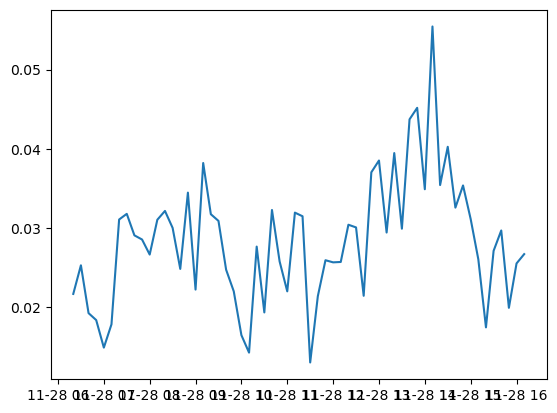

In [11]:
m1_vel = np.mean(np.sqrt(data['ADCP1_UVSSC_REV'][0]**2 + data['ADCP1_UVSSC_REV'][1]**2), 1)
nivel1 = data['ADCP1_depth_REV']
density1 = np.zeros(len(data['ADCP1_depth_REV']))*0 + np.nanmean(ctd1[6,:,13])
sed_size = 0.000020
time1 = data['ADCP1_time_REV']

tc_1 = shear_wc(m1_vel, density1, nivel1, sed_size)
plt.plot(time1, tc_1)

erro


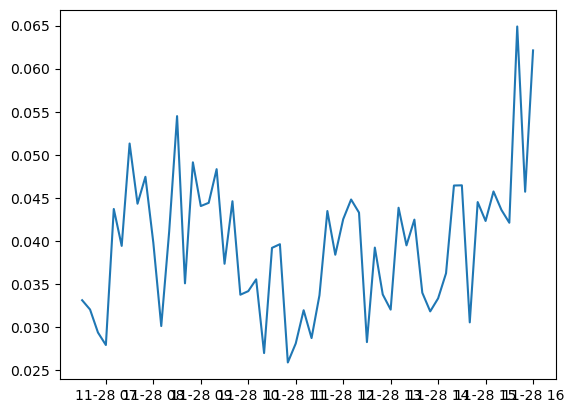

In [12]:
m2_vel = np.mean(np.sqrt(data['ADCP2_UVSSC_REV'][0]**2 + data['ADCP2_UVSSC_REV'][1]**2), 1)
nivel2 = data['ADCP2_depth_REV']
density2 = np.zeros(len(data['ADCP2_depth_REV']))*0 + np.nanmean(ctd1[6,:,8])
sed_size = 0.000020
time2 = data['ADCP2_time_REV']

tc_2 = shear_wc(m2_vel, density2, nivel2, sed_size)
plt.plot(time2[:-1], tc_2)

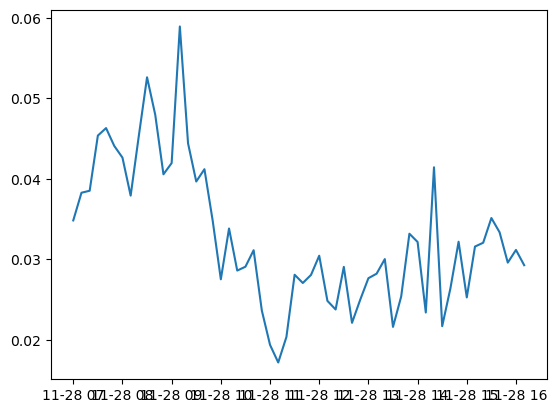

In [13]:
m3_vel = np.mean(np.sqrt(data['ADCP3_UVSSC_REV'][0]**2 + data['ADCP3_UVSSC_REV'][1]**2), 1)
nivel3 = data['ADCP3_depth_REV']
density3 = np.zeros(len(data['ADCP3_depth_REV']))*0 + np.nanmean(ctd1[6,:,3])
sed_size = 0.000020
time3 = data['ADCP3_time_REV']

tc_3 = shear_wc(m3_vel, density3, nivel3, sed_size)
plt.plot(time3, tc_3)

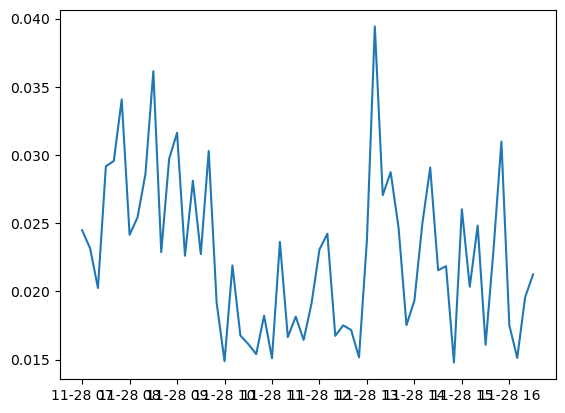

In [14]:
m4_vel = np.mean(np.sqrt(data['ADCP4_UVSSC_REV'][0]**2 + data['ADCP4_UVSSC_REV'][1]**2), 1)
nivel4 = data['ADCP4_depth_REV']
density4 = np.zeros(len(data['ADCP4_depth_REV']))*0 + np.nanmean(ctd1[6,:,0])
sed_size = 0.000020
time4 = data['ADCP4_time_REV']

tc_4 = shear_wc(m4_vel, density4, nivel4, sed_size)
plt.plot(time4, tc_4)

In [15]:
#numero de richardson a hora mais proxima

#teste
#ADCP-1
print(data['ADCP1_time_REV'][7])
g = 9.81
rho_0 = 1025
A_p = np.abs(ctd1[6,0,13] -ctd1[6,-34,13])
total_h = z_norm[-34]


du_dz = np.abs(data['ADCP1_UVSSC_REV'][0][7, 0] - data['ADCP1_UVSSC_REV'][0][7, -1])**2
dv_dz = np.abs(data['ADCP1_UVSSC_REV'][1][7, 0] - data['ADCP1_UVSSC_REV'][1][7, -1])**2


Ri_1 = g*A_p*total_h/rho_0*(du_dz+dv_dz)
Ri_1

2023-11-28 07:30:00


np.float64(nan)

2023-11-28 11:30:00


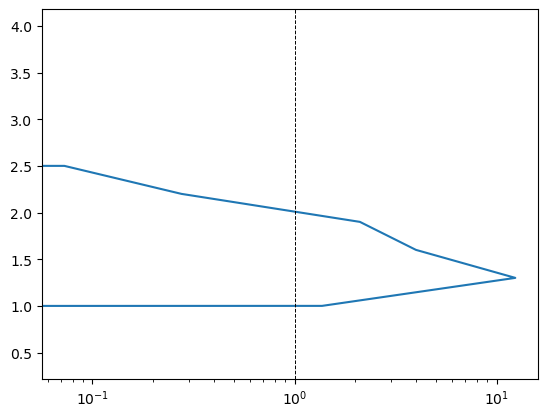

In [16]:
#ADCP-1
print(data['ADCP1_time_REV'][31])
g = 9.81
rho_0 = 1025


drho_dz = np.gradient(ctd2[6,:,5], z_norm)
du_dz = np.gradient(data['ADCP1_UVSSC_REV'][0][31, :], z1)
dv_dz = np.gradient(data['ADCP1_UVSSC_REV'][1][31, :], z1)

N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z1, z_norm, N_squared)

duv_dz = np.sqrt(du_dz**2 + dv_dz**2)

Ri_1 = N_squared_z1 / duv_dz**2
Ri_1_norm = Ri_1/0.25
plt.plot(Ri_1_norm, z1)
plt.xscale('log')
plt.axvline(x=1, ls = '--', lw =0.7,color ='k')

2023-11-28 07:20:00
-4.125


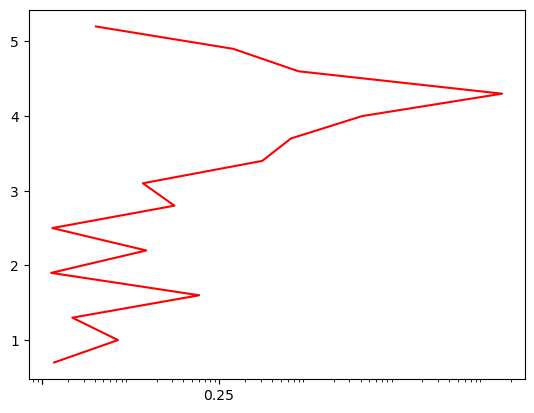

In [17]:
#Richardson ADCP-2
print(data['ADCP2_time_REV'][5])
g = 9.81
rho_0 = 1022


drho_dz = np.gradient(ctd1[6,:,8], z_norm)
du_dz = np.gradient(data['ADCP2_UVSSC_REV'][0][5, :], z2)
dv_dz = np.gradient(data['ADCP2_UVSSC_REV'][1][5, :], z2)

N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z2, z_norm, N_squared)

duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))

Ri_2 = N_squared_z1 / duv_dz**2
Ri_2_norm = Ri_2/0.25
plt.plot(np.flip(Ri_2_norm[:]), z2[:], color ='r')
plt.xscale('log')
plt.xticks([0.01, 1, 0.01],['', 0.25, ''])
np.interp(3.275, z2, np.flip(Ri_2_norm))
print(3.275 -7.4)


2023-11-28 07:10:00
-5.08


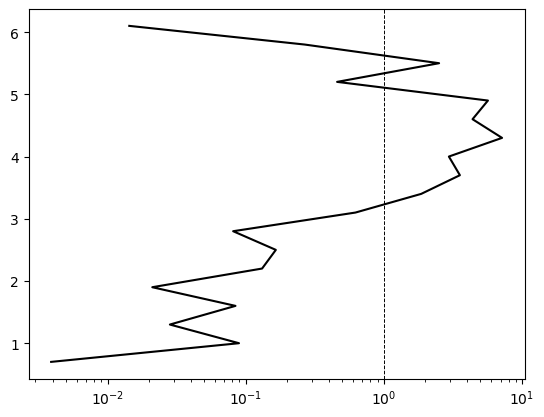

In [18]:
#Richardson ADCP-3
print(data['ADCP3_time_REV'][1])
g = 9.81
rho_0 = 1022


drho_dz = np.gradient(ctd1[6,:,3], z_norm)
du_dz = np.gradient(data['ADCP3_UVSSC_REV'][0][1, :], z3)
dv_dz = np.gradient(data['ADCP3_UVSSC_REV'][1][1, :], z3)

N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z3, z_norm, N_squared)

duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))

Ri_3 = N_squared_z1 / duv_dz**2
Ri_3_norm = Ri_3/0.25
plt.plot(np.flip(Ri_3_norm), z3, color ='k')
plt.xscale('log')
plt.axvline(x=1, ls = '--', lw =0.7,color ='k')
np.interp(3.42,  z3, np.flip(Ri_3_norm))
print(3.42 - 8.5)

2023-11-28 07:00:00
-5.5


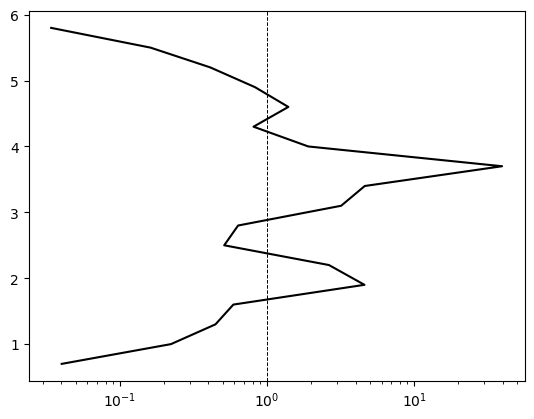

In [19]:
#Richardson ADCP-4
print(data['ADCP4_time_REV'][0])
g = 9.81
rho_0 = 1022


drho_dz = np.gradient(ctd1[6,:,0], z_norm)
du_dz = np.gradient(data['ADCP4_UVSSC_REV'][0][0, :], z4)
dv_dz = np.gradient(data['ADCP4_UVSSC_REV'][1][0, :], z4)

N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z4, z_norm, N_squared)

duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))

Ri_4 = N_squared_z1 / duv_dz**2
Ri_4_norm = Ri_4/0.25
plt.plot(Ri_4_norm, z4, color ='k')
plt.xscale('log')
plt.axvline(x=1, ls = '--', lw =0.7,color ='k')

np.interp(1.7,  z4, np.flip(Ri_4_norm))
print(1.7 - 7.2)

2023-11-28 07:30:00
2023-11-28 07:20:00
2023-11-28 07:10:00
2023-11-28 07:00:00


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


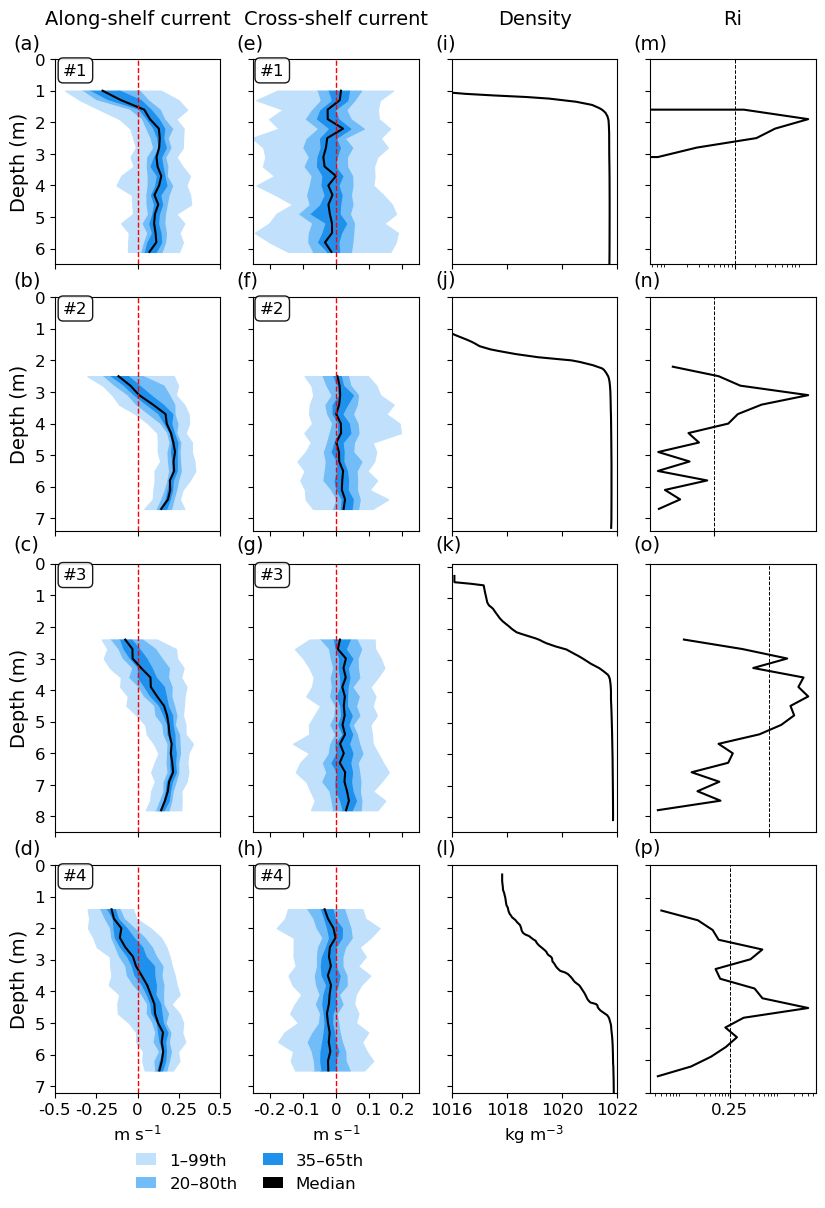

In [20]:
colors = ["#0B3861", "#1565C0", "#1976D2", "#1E88E5", "#2196F3", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB", "#E3F2FD"]
cmap = LinearSegmentedColormap.from_list("", colors)

# Array com as alturas proporcionais
depth = [6.5, 7.4, 8.5, 7.2]
total_depth = sum(depth)

# Calcula as alturas proporcionais
proportions = [d / total_depth for d in depth]

dx = 0.25  # Largura dos gráficos
spacing = 0.035  # Espaçamento ajustável entre as linhas

fig = plt.figure(figsize=(8.27*0.8, 11.69*0.8), dpi=100, constrained_layout=True)

# Função para calcular a posição vertical acumulada
def get_y_positions(proportions, spacing):
    positions = []
    current_y = 1.0  # Começar do topo da figura
    for p in proportions:
        positions.append(current_y - p)
        current_y -= (p + spacing)
    return positions

# Posições verticais para cada gráfico
y_positions = get_y_positions(proportions, spacing)

# Primeira coluna
ax1 = fig.add_axes([0.05, y_positions[0], dx, proportions[0]])
ax2 = fig.add_axes([0.05, y_positions[1], dx, proportions[1]])
ax3 = fig.add_axes([0.05, y_positions[2], dx, proportions[2]])
ax4 = fig.add_axes([0.05, y_positions[3], dx, proportions[3]])

# Segunda coluna
ax5 = fig.add_axes([0.35, y_positions[0], dx, proportions[0]])
ax6 = fig.add_axes([0.35, y_positions[1], dx, proportions[1]])
ax7 = fig.add_axes([0.35, y_positions[2], dx, proportions[2]])
ax8 = fig.add_axes([0.35, y_positions[3], dx, proportions[3]])

# Terceira coluna
ax9 = fig.add_axes([0.65, y_positions[0], dx, proportions[0]])
ax10 = fig.add_axes([0.65, y_positions[1], dx, proportions[1]])
ax11 = fig.add_axes([0.65, y_positions[2], dx, proportions[2]])
ax12 = fig.add_axes([0.65, y_positions[3], dx, proportions[3]])

# Quarta coluna
ax13 = fig.add_axes([0.95, y_positions[0], dx, proportions[0]])
ax14 = fig.add_axes([0.95, y_positions[1], dx, proportions[1]])
ax15 = fig.add_axes([0.95, y_positions[2], dx, proportions[2]])
ax16 = fig.add_axes([0.95, y_positions[3], dx, proportions[3]])



#1 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP1_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax1.fill_betweenx(z1, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax1.fill_betweenx(z1, guarda65, guarda80, z1, color = cmap(0.7), label='80th percentile')
ax1.fill_betweenx(z1, guarda50, guarda65, z1, color = cmap(0.4), label='65th percentile')
ax1.plot(guarda50, z1, 'k', label='Median')
ax1.fill_betweenx(z1, guarda35, guarda50, z1, color = cmap(0.4), label='35th percentile')
ax1.fill_betweenx(z1, guarda20, guarda35, z1, color = cmap(0.7), label='20th percentile')
ax1.fill_betweenx(z1, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax1.fill_betweenx(guarda01, z1, color = 'w')

ax1.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax1.set_xlim([-0.5, 0.5])
ax1.text(-0.25, 1.05, '(a)', transform=ax1.transAxes, fontsize=14)
ax1.set_ylim([0, 6.5])
ax1.set_ylabel('Depth (m)', fontsize=14)
ax1.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], [6, 5 , 4 , 3 , 2 , 1, 0], fontsize = 12)
ax1.set_xticklabels([])
ax1.annotate("#1", xy = (-0.45, 6), fontsize=12, bbox = boxatrib)


#2 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(15):
    g = np.transpose(data['ADCP2_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))#
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax2.fill_betweenx(z2[:15], guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax2.fill_betweenx(z2[:15], guarda65, guarda80, z2[:15], color = cmap(0.7), label='80th percentile')
ax2.fill_betweenx(z2[:15], guarda50, guarda65, z2[:15], color = cmap(0.4), label='65th percentile')
ax2.plot(guarda50, z2[:15], 'k', label='Median')
ax2.fill_betweenx(z2[:15], guarda35, guarda50, z2[:15], color = cmap(0.4), label='35th percentile')
ax2.fill_betweenx(z2[:15], guarda20, guarda35, z2[:15], color = cmap(0.7), label='20th percentile')
ax2.fill_betweenx(z2[:15], guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax2.fill_betweenx(guarda01, z2[:15], color = 'w')

ax2.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax2.set_xlim([-0.5, 0.5])
ax2.text(-0.25, 1.05, '(b)', transform=ax2.transAxes, fontsize=14)
ax2.set_ylim([0, 7.4])
ax2.set_ylabel('Depth (m)', fontsize=14)
ax2.set_yticks([.4, 1.4, 2.4, 3.4, 4.4, 5.4, 6.4, 7.4], [7, 6, 5, 4, 3, 2, 1, 0], fontsize = 12)
ax2.set_xticklabels([])
ax2.annotate("#2", xy = (-0.45, 6.9), fontsize=12, bbox = boxatrib)


#3 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(19):
    g = np.transpose(data['ADCP3_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax3.fill_betweenx(z3, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax3.fill_betweenx(z3, guarda65, guarda80, z3, color = cmap(0.7), label='80th percentile')
ax3.fill_betweenx(z3, guarda50, guarda65, z3, color = cmap(0.4), label='65th percentile')
ax3.plot(guarda50, z3, 'k', label='Median')
ax3.fill_betweenx(z3, guarda35, guarda50, z3, color = cmap(0.4), label='35th percentile')
ax3.fill_betweenx(z3, guarda20, guarda35, z3, color = cmap(0.7), label='20th percentile')
ax3.fill_betweenx(z3, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax3.fill_betweenx(guarda01, z3, color = 'w')

ax3.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax3.set_xlim([-0.5, 0.5])
ax3.text(-0.25, 1.05, '(c)', transform=ax3.transAxes, fontsize=14)
ax3.set_ylim([0, 8.5])
ax3.set_ylabel('Depth (m)', fontsize=14)
ax3.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5], [8, 7, 6, 5, 4, 3, 2, 1, 0], fontsize = 12)
ax3.set_xticklabels([])
ax3.annotate("#3", xy = (-0.45, 8), fontsize=12, bbox = boxatrib)


#4- U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP4_UVSSC_REV'][0][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax4.fill_betweenx(z4, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax4.fill_betweenx(z4, guarda65, guarda80, z4, color = cmap(0.7), label='80th percentile')
ax4.fill_betweenx(z4, guarda50, guarda65, z4, color = cmap(0.4), label='65th percentile')
ax4.plot(guarda50, z4, 'k', label='Median')
ax4.fill_betweenx(z4, guarda35, guarda50, z4, color = cmap(0.4), label='35th percentile')
ax4.fill_betweenx(z4, guarda20, guarda35, z4, color = cmap(0.7), label='20th percentile')
ax4.fill_betweenx(z4, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax4.fill_betweenx(guarda01, z4, color = 'w')

ax4.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax4.set_xlim([-0.5, 0.5])
ax4.set_xticks([-0.5, -0.25, 0, 0.25, 0.5], [-0.5, -0.25, 0, 0.25, 0.5], fontsize=12)
ax4.text(-0.25, 1.05, '(d)', transform=ax4.transAxes, fontsize=14)
ax4.set_ylim([0, 7.2])
ax4.set_ylabel('Depth (m)', fontsize=14)
ax4.set_yticks([.2, 1.2, 2.2, 3.2, 4.2, 5.2, 6.2, 7.2], [7, 6, 5, 4, 3, 2, 1, 0], fontsize = 12)
ax4.set_xlabel('m s$^{-1}$', fontsize=12)
ax4.annotate("#4", xy = (-0.45, 6.7), fontsize=12, bbox = boxatrib)


#5 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP1_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax5.fill_betweenx(z1, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax5.fill_betweenx(z1, guarda65, guarda80, z1, color = cmap(0.7), label='80th percentile')
ax5.fill_betweenx(z1, guarda50, guarda65, z1, color = cmap(0.4), label='65th percentile')
ax5.plot(guarda50, z1, 'k', label='Median')
ax5.fill_betweenx(z1, guarda35, guarda50, z1, color = cmap(0.4), label='35th percentile')
ax5.fill_betweenx(z1, guarda20, guarda35, z1, color = cmap(0.7), label='20th percentile')
ax5.fill_betweenx(z1, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax5.fill_betweenx(guarda01, z1, color = 'w')

ax5.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax5.set_xlim([-0.25, 0.25])
ax5.text(-0.1, 1.05, '(e)', transform=ax5.transAxes, fontsize=14)
ax5.set_ylim([0, 6.5])
ax5.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], [])
ax5.set_xticks([-.2, -.1, 0, .1, .2], [])
ax5.annotate("#1", xy = (-0.23, 6), fontsize=12, bbox = boxatrib)


#6 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(15):
    g = np.transpose(data['ADCP2_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))#
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax6.fill_betweenx(z2[:15], guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax6.fill_betweenx(z2[:15], guarda65, guarda80, z2[:15], color = cmap(0.7), label='80th percentile')
ax6.fill_betweenx(z2[:15], guarda50, guarda65, z2[:15], color = cmap(0.4), label='65th percentile')
ax6.plot(guarda50, z2[:15], 'k', label='Median')
ax6.fill_betweenx(z2[:15], guarda35, guarda50, z2[:15], color = cmap(0.4), label='35th percentile')
ax6.fill_betweenx(z2[:15], guarda20, guarda35, z2[:15], color = cmap(0.7), label='20th percentile')
ax6.fill_betweenx(z2[:15], guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax6.fill_betweenx(guarda01, z2[:15], color = 'w')

ax6.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax6.set_xlim([-0.25, 0.25])
ax6.text(-0.1, 1.05, '(f)', transform=ax6.transAxes, fontsize=14)
ax6.set_ylim([0, 7.4])
ax6.set_yticks([.4, 1.4, 2.4, 3.4, 4.4, 5.4, 6.4, 7.4], [])
ax6.set_xticks([-.2, -.1, 0, .1, .2], [])
ax6.annotate("#2", xy = (-0.23, 6.9), fontsize=12, bbox = boxatrib)

#7 - U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(19):
    g = np.transpose(data['ADCP3_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax7.fill_betweenx(z3, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax7.fill_betweenx(z3, guarda65, guarda80, z3, color = cmap(0.7), label='80th percentile')
ax7.fill_betweenx(z3, guarda50, guarda65, z3, color = cmap(0.4), label='65th percentile')
ax7.plot(guarda50, z3, 'k', label='Median')
ax7.fill_betweenx(z3, guarda35, guarda50, z3, color = cmap(0.4), label='35th percentile')
ax7.fill_betweenx(z3, guarda20, guarda35, z3, color = cmap(0.7), label='20th percentile')
ax7.fill_betweenx(z3, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax7.fill_betweenx(guarda01, z3, color = 'w')

ax7.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax7.set_xlim([-0.25, 0.25])
ax7.text(-0.1, 1.05, '(g)', transform=ax7.transAxes, fontsize=14)
ax7.set_ylim([0, 8.5])
ax7.set_yticks([.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5], [])
ax7.set_xticks([-.2, -.1, 0, .1, .2], [])
ax7.annotate("#3", xy = (-0.23, 8), fontsize=12, bbox = boxatrib)

#8- U
guarda01 = []
guarda20 = []
guarda35 = []
guarda50 = []
guarda65 = []
guarda80 = []
guarda99 = []

for i in range(18):
    g = np.transpose(data['ADCP4_UVSSC_REV'][1][:,i])
    g = np.array(g)
    trashx = np.linspace(0,1, len(g[~(np.isnan(g))]))
    trashy = np.sort(g[~(np.isnan(g))])
    guarda01.append(np.interp(0.01,trashx,trashy))
    guarda20.append(np.interp(0.20,trashx,trashy))
    guarda35.append(np.interp(0.35,trashx,trashy))
    guarda50.append(np.interp(0.50,trashx,trashy))
    guarda65.append(np.interp(0.65,trashx,trashy))
    guarda80.append(np.interp(0.80,trashx,trashy))
    guarda99.append(np.interp(0.99,trashx,trashy))

ax8.fill_betweenx(z4, guarda80, guarda99, color = cmap(0.9), label='99th percentile')
ax8.fill_betweenx(z4, guarda65, guarda80, z4, color = cmap(0.7), label='80th percentile')
ax8.fill_betweenx(z4, guarda50, guarda65, z4, color = cmap(0.4), label='65th percentile')
ax8.plot(guarda50, z4, 'k', label='Median')
ax8.fill_betweenx(z4, guarda35, guarda50, z4, color = cmap(0.4), label='35th percentile')
ax8.fill_betweenx(z4, guarda20, guarda35, z4, color = cmap(0.7), label='20th percentile')
ax8.fill_betweenx(z4, guarda01, guarda20, color = cmap(0.9), label='01th percentile')              
ax8.fill_betweenx(guarda01, z4, color = 'w')

ax8.axvline(x=0, linewidth=1, color='r', linestyle='--')
ax8.set_xlim([-0.25, 0.25])
ax8.set_xticks([-0.2, -0.1, 0, 0.1, 0.2], [-0.2, -0.1, 0, 0.1, 0.2], fontsize=14)
ax8.text(-0.1, 1.05, '(h)', transform=ax8.transAxes, fontsize=14)
ax8.set_ylim([0, 7.2])
ax8.set_yticks([.2, 1.2, 2.2, 3.2, 4.2, 5.2, 6.2, 7.2], [])
ax8.set_xlabel('m s$^{-1}$', fontsize=12)
ax8.set_xticks([-.2, -.1, 0, .1, .2], [-.2, -.1, 0, .1, .2], fontsize=12)
ax8.annotate("#4", xy = (-0.23, 6.7), fontsize=12, bbox = boxatrib)


ax9.plot(ctd1[6,:,13], -z_norm, color ='k')
ax9.set_xlim([1016, 1022])
ax9.set_ylim([-6.5, 0])
ax9.set_yticks([0, -1, -2, -3, -4, -5, -6], [])
ax9.text(-0.1, 1.05, '(i)', transform=ax9.transAxes, fontsize=14)
ax9.set_xticklabels([])
ax9.annotate("CTD-1 | 07h:28m", xy = (23.8, -.5), fontsize=14, bbox = boxatrib)


ax10.plot(ctd1[6,:,8], -z_norm, color ='k')
ax10.set_xlim([1016, 1022])
ax10.set_ylim([-7.4, 0])
ax10.set_yticks([0, -1, -2, -3, -4, -5, -6, -7], [])
ax10.text(-0.1, 1.05, '(j)', transform=ax10.transAxes, fontsize=14)
ax10.set_xticklabels([])
ax10.annotate("CTD-1 | 07h:20m", xy = (23.8, -.5), fontsize=14, bbox = boxatrib)


ax11.plot(ctd1[6,:,3], -z_norm, color ='k')
ax11.set_xlim([1016, 1022])
ax12.set_ylim([-8.5, 0])
ax11.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])
ax11.text(-0.1, 1.05, '(k)', transform=ax11.transAxes, fontsize=14)
ax11.set_xticklabels([])
ax11.annotate("CTD-1 | 07h:07m", xy = (23.8, -.5), fontsize=14, bbox = boxatrib)


ax12.plot(ctd1[6,:,0], -z_norm, color ='k')
ax12.set_xlim([1016, 1022])
ax12.set_xticks([1016, 1018, 1020, 1022], [1016, 1018, 1020, 1022], fontsize=12)
ax12.set_ylim([-7.2, 0])
ax12.set_yticks([0, -1, -2, -3, -4, -5, -6, -7], [])
ax12.text(-0.1, 1.05, '(l)', transform=ax12.transAxes, fontsize=14)
ax12.set_xlabel('kg m$^{-3}$', fontsize = 12)
ax12.annotate("CTD-1 | 06h:59m", xy = (23.8, -.5), fontsize=14, bbox = boxatrib)


#Richardson ADCP-1
print(data['ADCP1_time_REV'][7])
g = 9.81
rho_0 = 1022
drho_dz = np.gradient(ctd1[6,:,13], z_norm)
du_dz = np.gradient(data['ADCP1_UVSSC_REV'][0][7, :], z1)
dv_dz = np.gradient(data['ADCP1_UVSSC_REV'][1][7, :], z1)
N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z1, z_norm, N_squared)
duv_dz = np.sqrt(du_dz**2 + dv_dz**2)
duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))
Ri_1_norm = Ri_1/0.25
ax13.plot(np.flip(Ri_1_norm), z1.T - 6.5, color ='k')
ax13.text(-0.1, 1.05, '(m)', transform=ax13.transAxes, fontsize=14)
ax13.set_xticks([0.01, 1, 0.01],['', 0.25, ''])
ax13.set_xscale('log')
ax13.axvline(x=1, ls = '--', lw =0.7, color ='k')
ax13.set_ylim([-6.5, 0])
ax13.set_yticks([0, -1, -2, -3, -4, -5, -6], [])
ax13.set_xticks([1],[''])

#Richardson ADCP-2
print(data['ADCP2_time_REV'][5])
g = 9.81
rho_0 = 1022
drho_dz = np.gradient(ctd1[6,:,8], z_norm)
du_dz = np.gradient(data['ADCP2_UVSSC_REV'][0][5, :], z2)
dv_dz = np.gradient(data['ADCP2_UVSSC_REV'][1][5, :], z2)
N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z2, z_norm, N_squared)
duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))
Ri_2 = N_squared_z1 / duv_dz**2
Ri_2_norm = Ri_2/0.25
ax14.plot(np.flip(Ri_2_norm), z2.T-7.4, color ='k')
ax14.text(-0.1, 1.05, '(n)', transform=ax14.transAxes, fontsize=14)
ax14.set_xticks([0.01, 1, 0.01],['', 0.25, ''])
ax14.set_xscale('log')
ax14.axvline(x=1, ls = '--', lw =0.7,color ='k')
ax14.set_ylim([-7.4, 0])
ax14.set_yticks([0, -1, -2, -3, -4, -5, -6, -7], [])
ax14.set_xticks([1],[''])


#Richardson ADCP-3
print(data['ADCP3_time_REV'][1])
g = 9.81
rho_0 = 1022
drho_dz = np.gradient(ctd1[6,:,3], z_norm)
du_dz = np.gradient(data['ADCP3_UVSSC_REV'][0][1, :], z3)
dv_dz = np.gradient(data['ADCP3_UVSSC_REV'][1][1, :], z3)
N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z3, z_norm, N_squared)
duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))
Ri_3 = N_squared_z1 / duv_dz**2
Ri_3_norm = Ri_3/0.25
ax15.plot(np.flip(Ri_3_norm), z3.T - 8.5, color ='k')
ax15.text(-0.1, 1.05, '(o)', transform=ax15.transAxes, fontsize=14)
ax15.axvline(x=1, ls = '--', lw =0.7,color ='k')
ax15.set_ylim([-8.5, 0])
ax15.set_yticks([0, -1, -2, -3, -4, -5, -6, -7, -8], [])
ax15.set_xscale('log')
ax15.set_xticks([1],[''])

#Richardson ADCP-4
print(data['ADCP4_time_REV'][0])
g = 9.81
rho_0 = 1022
drho_dz = np.gradient(ctd1[6,:,0], z_norm)
du_dz = np.gradient(data['ADCP4_UVSSC_REV'][0][0, :], z4)
dv_dz = np.gradient(data['ADCP4_UVSSC_REV'][1][0, :], z4)
N_squared = (g / rho_0) * drho_dz
N_squared_z1 = np.interp(z4, z_norm, N_squared)
duv_dz = np.flip(np.sqrt(du_dz**2 + dv_dz**2))
Ri_4 = N_squared_z1 / duv_dz**2
Ri_4_norm = Ri_4/0.25
ax16.plot(np.flip(Ri_4_norm), z4.T - 7.2, color ='k')
ax16.text(-0.1, 1.05, '(p)', transform=ax16.transAxes, fontsize=14)
ax16.axvline(x=1, ls = '--', lw =0.7,color ='k')
ax16.set_yticks([0, -1, -2, -3, -4, -5, -6, -7], [])
ax16.set_xscale('log')
ax16.set_xticks([1],[0.25], fontsize = 12)





ax1.set_title('Along-shelf current', pad = 25, fontsize = 14)
ax5.set_title('Cross-shelf current', pad = 25, fontsize = 14)
ax9.set_title('Density', pad = 25, fontsize = 14)
ax13.set_title('Ri', pad = 25, fontsize = 14)


legend_elements = [
    Patch(facecolor=cmap(0.9), label='1–99th'),
    Patch(facecolor=cmap(0.7), label='20–80th'),
    Patch(facecolor=cmap(0.4), label='35–65th'),
    Patch(facecolor='k', label='Median')
]

ax4.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(0.4, -0.2),   # posição fora do eixo
    ncol=2,                         # elementos na horizontal
    fontsize=12,
    frameon=False,
    columnspacing=1.5,
    handlelength=1.2
)